In [7]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision.transforms import ToTensor

from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

# ========= Model Setup =========
def get_instance_segmentation_model(num_classes):
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
    return model

def segment_sudoku(img, model, device, threshold=0.5):
    """
    Segments Sudoku grids in an image using a trained Mask R-CNN model.
    
    Args:
        img (np.ndarray): image to segment.
        model (torch.nn.Module): Trained Mask R-CNN model.
        device (torch.device): torch.device('cuda') or torch.device('cpu')
        threshold (float): Minimum score for considering a detection.
    
    Returns:
        output_img (np.ndarray): Original image with masks drawn.
    """
    h, w, _ = img.shape

    # Convert to tensor and add batch dimension
    img_tensor = ToTensor()(img).to(device)
    model.eval()
    with torch.no_grad():
        outputs = model([img_tensor])
    
    # Get masks, scores, and labels
    masks = outputs[0]['masks']  # (N, 1, H, W)
    scores = outputs[0]['scores']
    
    # Filter by threshold
    masks = masks[scores > threshold]
    
    if len(masks) == 0:
        return img  # nothing detected
    
    # Combine masks into a single mask
    combined_mask = torch.zeros((h, w), dtype=torch.uint8).to(device)
    for mask in masks:
        mask_binary = (mask[0] > 0.5).byte()  # threshold mask
        combined_mask = torch.max(combined_mask, mask_binary)
    
    combined_mask = combined_mask.cpu().numpy() * 255
    
    # Create colored mask overlay
    colored_mask = np.zeros_like(img)
    colored_mask[:, :, 1] = combined_mask  # green mask
    alpha = 0.5
    output_img = cv2.addWeighted(img, 1, colored_mask, alpha, 0)
    
    return output_img



def segment_sudoku_quad(img, model, device, threshold=0.5, alpha=0.4):
    """
    Detects Sudoku grids using a trained Mask R-CNN model and
    draws filled quadrilateral polygons around each detected mask.
    
    Args:
        img (np.ndarray): Image to process (BGR or RGB).
        model (torch.nn.Module): Trained Mask R-CNN model.
        device (torch.device): torch.device('cuda') or torch.device('cpu').
        threshold (float): Minimum score for considering a detection.
        alpha (float): Transparency for filled polygons (0-1).
    
    Returns:
        output_img (np.ndarray): Original image with filled quads drawn.
    """
    img_out = img.copy()
    overlay = img.copy()
    h, w, _ = img.shape

    # Convert to tensor
    img_tensor = ToTensor()(img).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model([img_tensor])

    masks = outputs[0]['masks']  # (N, 1, H, W)
    scores = outputs[0]['scores']

    # Filter by threshold
    masks = masks[scores > threshold]

    if len(masks) == 0:
        return img_out  # nothing detected

    # Combine masks into a single mask
    combined_mask = torch.zeros((h, w), dtype=torch.uint8).to(device)
    for mask in masks:
        mask_binary = (mask[0] > 0.5).byte()
        combined_mask = torch.max(combined_mask, mask_binary)
    combined_mask = combined_mask.cpu().numpy() * 255

    # Find external contours
    contours, _ = cv2.findContours(combined_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return img_out

    # Take the largest contour
    contour = max(contours, key=cv2.contourArea)

    # Approximate contour with a polygon
    epsilon = 0.02 * cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, epsilon, True)

    # If more than 4 points, fit 4-point bounding quadrilateral
    if len(approx) > 4:
        rect = cv2.minAreaRect(contour)
        approx = cv2.boxPoints(rect)
        approx = np.int32(approx)

    # Fill polygon on overlay
    cv2.fillPoly(overlay, [approx], color=(0, 255, 0))  # green fill
    # Draw outline
    cv2.polylines(overlay, [approx], isClosed=True, color=(0, 200, 0), thickness=2)

    # Blend overlay with original image
    cv2.addWeighted(overlay, alpha, img_out, 1 - alpha, 0, img_out)

    return img_out, approx.reshape(-1, 2)


/tmp/ipykernel_38708/3537803441.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("maskrcnn_sudoku.pth", map_location=device))


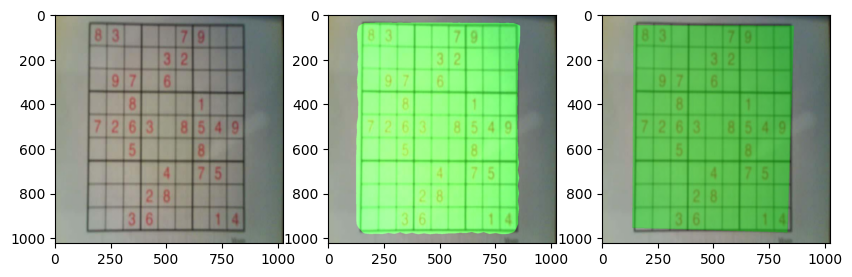

In [8]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Load trained model
num_classes = 2
model = get_instance_segmentation_model(num_classes)
model.load_state_dict(torch.load("maskrcnn_sudoku.pth", map_location=device))
model.to(device)

# Segment image

image  = cv2.imread('/home/viny/Desktop/Sudoku-Solver/Sudoku.v1i.yolov8/test/images/12d8cbcc-image168_jpg.rf.f46b55161d27f88b24128bad4abbf212.jpg')
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = cv2.resize(image, (1024, 1024))
mask_drawn = segment_sudoku(image, model, device)
polygon_drawn, approx = segment_sudoku_quad(image, model, device)

fig, axs = plt.subplots(1,3, figsize=(10, 5))
axs[0].imshow(image)
axs[1].imshow(mask_drawn)
axs[2].imshow(polygon_drawn)
plt.show()

In [9]:
approx

array([[142,  46],
       [137, 955],
       [832, 975],
       [861,  48]], dtype=int32)

In [10]:
def warp_sudoku(img, quad_points, size=450):
    """
    Warps a detected Sudoku grid to a square, rectified view using homography.

    Args:
        img (np.ndarray): Original image (BGR or RGB).
        quad_points (np.ndarray): 4 corner points of the Sudoku grid (Nx2).
        size (int): Output size of the square grid.

    Returns:
        warped (np.ndarray): Rectified square image of the Sudoku grid.
    """
    # Ensure quad_points are float32 and sorted in consistent order
    pts = np.array(quad_points, dtype=np.float32)

    # Sort points: top-left, top-right, bottom-right, bottom-left
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)
    rect = np.zeros((4,2), dtype=np.float32)
    rect[0] = pts[np.argmin(s)]  # top-left
    rect[2] = pts[np.argmax(s)]  # bottom-right
    rect[1] = pts[np.argmin(diff)]  # top-right
    rect[3] = pts[np.argmax(diff)]  # bottom-left

    # Destination points for warp (square)
    dst = np.array([
        [0, 0],
        [size-1, 0],
        [size-1, size-1],
        [0, size-1]
    ], dtype=np.float32)

    # Compute homography
    H, _ = cv2.findHomography(rect, dst)

    # Warp the image
    warped = cv2.warpPerspective(img, H, (size, size))

    return warped


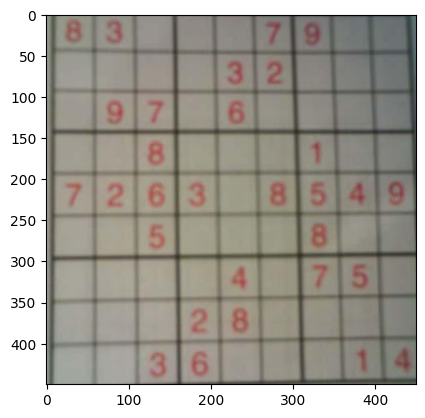

In [12]:
# Suppose segment_sudoku_quad_filled returned approx polygon points:
img_rectified = warp_sudoku(image, approx, size=450)
plt.imshow(img_rectified)